# Filtering TM/TR CDF plot (stencil 0617 dsub)

Based on 0616. The standalone EP/ER cell is merged into the DR cell: the WD bars are drawn once,
with DR on the right axis and per-timer eps_P/eps_R threshold arrows on top of each bar.
Thresholds (EP_THRESHOLD / ER_THRESHOLD) are rough placeholders -- tune by hand.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
DATE_BASE = "20260630"
HOST_ORDER = ["cgnr6760pn2", "camd9554n1", "c920bn3"]
SHUFFLE_SELECT = "shuffle1"
RUN_ID = "20260630-jacobi-after-full-dsub"
OUTPUT_ROOT = "output_jacobi_after_full_0630_dsub"

# 0630 Jacobi-after full run: explicit shuffle directories, no latest-run selection.
# Pudding override: c920bn3 uses the ARM true-serialization rerun; x86 hosts remain original 0630 data.
C920_ARM_SERIALIZE_RUN_ID = "20260630-jacobi-after-full-armserialize-dsub"
RUN_ROOT_OVERRIDES = {
    "cgnr6760pn2": Path(f"/astrum/home/hpchzy/code/data/{DATE_BASE}/cgnr6760pn2/{OUTPUT_ROOT}/{RUN_ID}/{SHUFFLE_SELECT}"),
    "camd9554n1": Path(f"/astrum/home/hpchzy/code/data/{DATE_BASE}/camd9554n1/{OUTPUT_ROOT}/{RUN_ID}/{SHUFFLE_SELECT}"),
    "c920bn3": Path(f"/astrum/home/hpchzy/code/data/{DATE_BASE}/c920bn3/{OUTPUT_ROOT}/{C920_ARM_SERIALIZE_RUN_ID}/{SHUFFLE_SELECT}"),
}


def latest_run_root(host, shuffle_select=SHUFFLE_SELECT):
    if host in RUN_ROOT_OVERRIDES:
        return RUN_ROOT_OVERRIDES[host]
    raise RuntimeError(f"Missing explicit RUN_ROOT_OVERRIDES entry for {host}")

RUN_ROOTS = [latest_run_root(host, SHUFFLE_SELECT).parent for host in HOST_ORDER]
DATA_FOLDERS = [latest_run_root(host, SHUFFLE_SELECT) for host in HOST_ORDER]
SHUFFLE_LABEL = "_".join(f"{host}-{Path(root).name}" for host, root in zip(HOST_ORDER, DATA_FOLDERS))

QUANTILE_DROP = 1.0
SAVE_FIG = True
OUT_DIR = Path('/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_jacobi_after_full_dsub')

TIMER_COLORS = {
    'cgt': '#ff7f0e',
    'clock_gettime': '#ff7f0e',
    'wtime': '#2ca02c',
    'mpi_wtime': '#2ca02c',
    'papi': '#d62728',
    'papix6': '#9467bd',
    'likwid': '#8c564b',
    'tsc': '#1f77b4',
    'tsc_fence': '#4f8dd3',
    'tsc_native': '#17becf',
    'cntvct': '#e377c2',
    'cntvcto': '#e377c2',
}

TIMER_LABELS = {
    'tsc': 'TSC',
    'tsc_fence': 'TSC_Fence',
    'tsc_native': 'TSC_Native',
    'cgt': 'clock_gettime',
    'clock_gettime': 'clock_gettime',
    'wtime': 'MPI_Wtime',
    'mpi_wtime': 'MPI_Wtime',
    'papi': 'PAPI',
    'papix6': 'PAPIx6',
    'likwid': 'LIKWID',
    'cntvct': 'CNTVCT',
    'cntvcto': 'CNTVCTO',
}

KERNEL_LABELS = {
    'jacobi2d5p': '2D 5-Point Jacobi Stencil',
    'tl_f90_cg_calc_w': 'TL F90 CG',
    'gs2d5p': '2D 5-Point Gauss-Seidel',
}

HOST_LABELS = {
    "cgnr6760pn2": "Intel Xeon 6760P",
    "camd9554n1": "AMD EPYC 9554",
    "camd9554n2": "AMD EPYC 9554",
    "c920bn3": "Kunpeng 920B",
}

for root in DATA_FOLDERS:
    print(root)
print("host_order:", HOST_ORDER)
print("shuffle_label:", SHUFFLE_LABEL)


/astrum/home/hpchzy/code/data/20260630/cgnr6760pn2/output_jacobi_after_full_0630_dsub/20260630-jacobi-after-full-dsub/shuffle1
/astrum/home/hpchzy/code/data/20260630/camd9554n1/output_jacobi_after_full_0630_dsub/20260630-jacobi-after-full-dsub/shuffle1
/astrum/home/hpchzy/code/data/20260630/c920bn3/output_jacobi_after_full_0630_dsub/20260630-jacobi-after-full-armserialize-dsub/shuffle1
host_order: ['cgnr6760pn2', 'camd9554n1', 'c920bn3']
shuffle_label: cgnr6760pn2-shuffle1_camd9554n1-shuffle1_c920bn3-shuffle1


In [3]:
def parse_filt_dir(path):
    m = re.match(r'(?P<prefix>.+)_np(?P<np>\d+)_size(?P<size>\d+)_nsampRatio(?P<nsampRatio>[\d.]+)_nsamp(?P<nsamp>\d+)_filt$', path.name)
    if not m:
        return None
    d = m.groupdict()
    prefix = d.pop('prefix')
    kernel = None
    timer = None
    for candidate in sorted(TIMER_LABELS, key=len, reverse=True):
        suffix = f'_{candidate}'
        if prefix.endswith(suffix):
            kernel = prefix[:-len(suffix)]
            timer = candidate
            break
    if not kernel or not timer:
        return None
    d['kernel'] = kernel
    d['timer'] = timer
    d['np'] = int(d['np'])
    d['size'] = int(d['size'])
    d['nsamp'] = int(d['nsamp'])
    d['nsampRatio'] = float(d['nsampRatio'])
    return d


def host_from_data_folder(data_folder):
    parts = Path(data_folder).parts
    if 'data' in parts:
        i = parts.index('data')
        if len(parts) > i + 2:
            return parts[i + 2]
    return Path(data_folder).name


def timer_label(timer):
    return TIMER_LABELS.get(timer, timer.upper().replace('_', '-'))


def timer_sort_key(timer):
    order = ['tsc', 'tsc_fence', 'tsc_native', 'cntvct', 'cntvcto', 'cgt', 'clock_gettime', 'wtime', 'mpi_wtime', 'papi', 'papix6', 'likwid']
    return (order.index(timer) if timer in order else len(order), timer)


def ecdf_xy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = np.sort(vals)
    if vals.size == 0:
        return vals, vals
    y = np.arange(1, vals.size + 1) / vals.size
    keep = y <= QUANTILE_DROP
    x = vals[keep]
    y = y[keep]
    if x.size:
        x = np.r_[x[0], x]
        y = np.r_[0.0, y]
    return x, y


def read_tm(tm_file):
    df = pd.read_csv(tm_file, header=None, names=['ns'])
    return df['ns'].to_numpy()


def read_tr(tr_hist_file):
    """Read tr_hist.csv as piecewise-linear CDF.

    Format: (left_edge, prob) per row; bin [t_i, t_{i+1}) has probability prob_i;
    last row is sentinel with prob=0 (right boundary).
    Returns df with cdf[i] = cumulative probability at LEFT edge of bin i,
    so plotting ns vs cdf gives a diagonal piecewise-linear CDF (not step function).
    """
    df = pd.read_csv(tr_hist_file, header=None, names=['ns', 'prob'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    df['prob'] = pd.to_numeric(df['prob'], errors='coerce')
    df = df[np.isfinite(df['ns']) & np.isfinite(df['prob'])].copy()
    df.sort_values('ns', inplace=True)
    total = df['prob'].sum()
    if total > 0:
        df['prob'] = df['prob'] / total
    cs = df['prob'].cumsum()
    # Keep bins whose LEFT edge starts below QUANTILE_DROP, plus one right-boundary row.
    left_cdf = cs.shift(1, fill_value=0.0)
    keep = left_cdf < QUANTILE_DROP
    if keep.any():
        iloc_last = df.index.get_loc(keep[keep].index[-1])
        if iloc_last + 1 < len(df):
            keep.iloc[iloc_last + 1] = True
    df = df[keep].copy()
    # cdf[i] = CDF at left edge of bin i = sum of probs of all PREVIOUS bins
    df['cdf'] = df['prob'].cumsum().shift(1, fill_value=0.0)
    return df


def collect_entries(data_folder):
    rows = []
    data_folder = Path(data_folder)
    host = host_from_data_folder(data_folder)
    for tr_hist_file in sorted(data_folder.glob('*/tr_hist.csv')):
        filt_dir = tr_hist_file.parent
        meta = parse_filt_dir(filt_dir)
        if meta is None:
            continue
        tm_file = filt_dir / 'met.csv'
        if not tm_file.exists():
            print(f'skip missing met.csv: {filt_dir}')
            continue
        rows.append({**meta, 'host': host, 'data_folder': data_folder, 'shuffle': data_folder.name, 'filt_dir': filt_dir, 'tm_file': tm_file, 'tr_hist_file': tr_hist_file})
    return pd.DataFrame(rows)

entries = pd.concat([collect_entries(p) for p in DATA_FOLDERS], ignore_index=True)
print(f'entries: {len(entries)}')
entries.sort_values(['host', 'kernel', 'np', 'size', 'timer']).head(20)
entries = entries[(entries['timer'] != 'tsc_native') & (entries['timer'] != 'cntvct')]
# 0630 keeps CNTVCTO distinct; raw CNTVCT is intentionally not run.
# entries = entries[(entries['timer'] != 'papi') & (entries['timer'] != 'cgt')]


entries: 90


# ER/EP/Wasserstein

In [4]:
from scipy.stats import wasserstein_distance


def read_float_file(path):
    try:
        text = Path(path).read_text().strip()
        return float(text) if text else np.nan
    except FileNotFoundError:
        print(f'warning: missing {path}')
        return np.nan
    except ValueError:
        print(f'warning: invalid float in {path}')
        return np.nan


def clean_hist_for_wd(hist_file, ns_col='ns', pr_col='pr'):
    df = pd.read_csv(hist_file, header=None, names=[ns_col, pr_col])
    df[ns_col] = pd.to_numeric(df[ns_col], errors='coerce')
    df[pr_col] = pd.to_numeric(df[pr_col], errors='coerce')
    df = df[np.isfinite(df[ns_col]) & np.isfinite(df[pr_col])].copy()
    df = df[df[pr_col] > 0]
    if df.empty or df[pr_col].sum() <= 0:
        return None
    return df


def wd_to_min(hist_file):
    df = clean_hist_for_wd(hist_file)
    if df is None:
        return np.nan
    ns = df['ns'].to_numpy(dtype=float)
    pr = df['pr'].to_numpy(dtype=float)
    return wasserstein_distance(ns, np.array([ns.min()]), pr, np.array([1.0]))


def read_hist_for_sampling(hist_file):
    """Read (lb, pr) histogram into (lb, rb, pr) DataFrame for quantile sampling."""
    try:
        tmp = pd.read_csv(hist_file, header=None, names=['lb', 'pr'])
    except Exception:
        return None
    tmp['lb'] = pd.to_numeric(tmp['lb'], errors='coerce')
    tmp['pr'] = pd.to_numeric(tmp['pr'], errors='coerce').fillna(0.0)
    tmp = tmp.dropna(subset=['lb']).reset_index(drop=True)
    m = ~np.isclose(tmp['pr'], 0)
    if not m.any():
        return None
    last_nz = int(np.where(m)[0][-1])
    if last_nz + 1 >= len(tmp):
        return None
    tmp = tmp.iloc[:last_nz + 2].copy()
    tmp['rb'] = tmp['lb'].shift(-1)
    tmp['lb'] = tmp['lb'].astype(np.float64)
    tmp = tmp[['lb', 'rb', 'pr']].iloc[:-1].dropna()
    return tmp if not tmp.empty else None


def sample_from_bins_quantile(tmp_df, n=1000):
    lb = tmp_df['lb'].to_numpy()
    rb = tmp_df['rb'].to_numpy()
    pr = tmp_df['pr'].to_numpy()
    pr = pr / pr.sum()
    p0 = np.r_[0, np.cumsum(pr)]
    q = (np.arange(n) + 0.5) / n
    idx = np.searchsorted(p0[1:], q, side='right')
    local_t = (q - p0[idx]) / pr[idx]
    return lb[idx] + local_t * (rb[idx] - lb[idx])


SEQ_N = 1000

summary_rows = []
for idx, row in entries.iterrows():
    filt_folder = Path(row['filt_dir'])
    ep = read_float_file(filt_folder / 'ep.out')
    er = read_float_file(filt_folder / 'er.out')
    wd = read_float_file(filt_folder / 'wd.out')
    tm_wd = wd_to_min(filt_folder / 'tm_hist.csv')
    tr_wd = wd_to_min(filt_folder / 'tr_hist.csv')
    if not np.isfinite(tm_wd) or not np.isfinite(tr_wd):
        print(f"warning: invalid histogram for Wasserstein: {filt_folder.name} tm_wd={tm_wd} tr_wd={tr_wd}")
    _tr_h = read_hist_for_sampling(filt_folder / 'tr_hist.csv')
    _tm_h = read_hist_for_sampling(filt_folder / 'tm_hist.csv')
    tr_seq = sample_from_bins_quantile(_tr_h, SEQ_N) if _tr_h is not None else None
    tm_seq = sample_from_bins_quantile(_tm_h, SEQ_N) if _tm_h is not None else None
    summary_rows.append({**row.to_dict(), 'ep': ep, 'er': er, 'wd': wd, 'tm_wd': tm_wd, 'tr_wd': tr_wd, 'tr_seq': tr_seq, 'tm_seq': tm_seq})

df = pd.DataFrame(summary_rows).reset_index(drop=True)
df.sort_values(['host', 'kernel', 'np', 'size', 'timer'], inplace=True)

df = df[~df['kernel'].str.contains('tsc')]

df[['host', 'kernel', 'timer', 'np', 'size', 'ep', 'er', 'wd', 'tm_wd', 'tr_wd']].head(20)  # tr_seq/tm_seq stored as object columns


,host,kernel,timer,np,size,ep,er,wd,tm_wd,tr_wd
65,c920bn3,jacobi2d5p,cgt,64,64,0.034928,0.081520,7.273367,8.892974,8.892970
71,c920bn3,jacobi2d5p,cntvcto,64,64,0.000000,0.045560,3.403015,0.000000,0.000000
77,c920bn3,jacobi2d5p,papi,64,64,0.011752,0.030512,6.475377,12.113437,12.113440
83,c920bn3,jacobi2d5p,papix6,64,64,0.000025,0.034923,7.567839,13.005332,13.005330
89,c920bn3,jacobi2d5p,wtime,64,64,0.124490,0.072471,5.816080,9.795468,9.795460
61,c920bn3,jacobi2d5p,cgt,64,128,0.000000,0.035460,5.976884,16.169466,6.559140
67,c920bn3,jacobi2d5p,cntvcto,64,128,0.000000,0.036806,4.771859,9.305949,5.182000
73,c920bn3,jacobi2d5p,papi,64,128,0.019418,0.020704,5.678392,14.019042,14.019040
79,c920bn3,jacobi2d5p,papix6,64,128,0.077204,0.026143,7.395980,20.810315,17.858660
85,c920bn3,jacobi2d5p,wtime,64,128,0.000000,0.051167,7.643216,17.822843,10.766340


In [5]:
print(df['kernel'].unique())
df.query('np==64 and nsampRatio==0.5 and kernel=="jacobi2d5p" and host=="camd9554n1"')
for k,v in df.groupby(['np','nsampRatio','shuffle','kernel','host']):
    print(k)
    v['tm_median'] = v['tm_seq'].apply(np.median)
    print(v.columns)
    print(v[['kernel','size','host','tm_median']])

['jacobi2d5p']
(np.int64(64), np.float64(0.5), 'shuffle1', 'jacobi2d5p', 'c920bn3')
Index(['np', 'size', 'nsampRatio', 'nsamp', 'kernel', 'timer', 'host',
       'data_folder', 'shuffle', 'filt_dir', 'tm_file', 'tr_hist_file', 'ep',
       'er', 'wd', 'tm_wd', 'tr_wd', 'tr_seq', 'tm_seq', 'tm_median'],
      dtype='object')
        kernel  size     host    tm_median
65  jacobi2d5p    64  c920bn3    94.377584
71  jacobi2d5p    64  c920bn3    75.500000
77  jacobi2d5p    64  c920bn3   216.443779
83  jacobi2d5p    64  c920bn3   222.083940
89  jacobi2d5p    64  c920bn3    83.895598
61  jacobi2d5p   128  c920bn3   173.815504
67  jacobi2d5p   128  c920bn3   134.627093
73  jacobi2d5p   128  c920bn3   278.797222
79  jacobi2d5p   128  c920bn3   284.120772
85  jacobi2d5p   128  c920bn3   153.389223
63  jacobi2d5p   256  c920bn3   307.393775
69  jacobi2d5p   256  c920bn3   243.883778
75  jacobi2d5p   256  c920bn3   389.125157
81  jacobi2d5p   256  c920bn3   391.489889
87  jacobi2d5p   256  c920bn3

In [6]:
# df["timer_label"] = df["timer"].map(TIMER_LABELS).fillna(df["timer"])
# df["kernel_label"] = df["kernel"].map(KERNEL_LABELS).fillna(df["kernel"])

# df['shuffle'] = df['shuffle'].astype('string')
# df
# for k,v_df in df.groupby(['np','size','host','nsampRatio','nsamp','kernel','host','shuffle']):
#     print(k)
#     print(v_df.columns)

divergence_table group ('jacobi2d5p', 'c920bn3', np.int64(256), np.float64(0.5)): base=243.2954755965825 sum_tm=376.94688255395437 sum_tr=69.35062073013137 reduction=0.8160201770067568
divergence_table group ('jacobi2d5p', 'camd9554n1', np.int64(256), np.float64(0.5)): base=218.65006240301932 sum_tm=1241.8639743194253 sum_tr=29.440088561833264 reduction=0.9762936286335487
divergence_table group ('jacobi2d5p', 'cgnr6760pn2', np.int64(256), np.float64(0.5)): base=278.68329764494325 sum_tm=388.32647052035264 sum_tr=33.42954550427109 reduction=0.9139138121089817
[WD / divergence Tm->Tr + eps]  kernel=2D 5-Point Jacobi Stencil  cgnr6760pn2-shuffle1_camd9554n1-shuffle1_c920bn3-shuffle1  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']  ref_by_host={'Intel Xeon 6760P': 'tsc', 'AMD EPYC 9554': 'tsc', 'Kunpeng 920B': 'cntvcto'}
kernel=jacobi2d5p h ost=cgnr6760pn2  before: [np.float64(108.46552721086016), np.float64(61.76293719992402), np.float64(34.83582204261667), np.float64(3

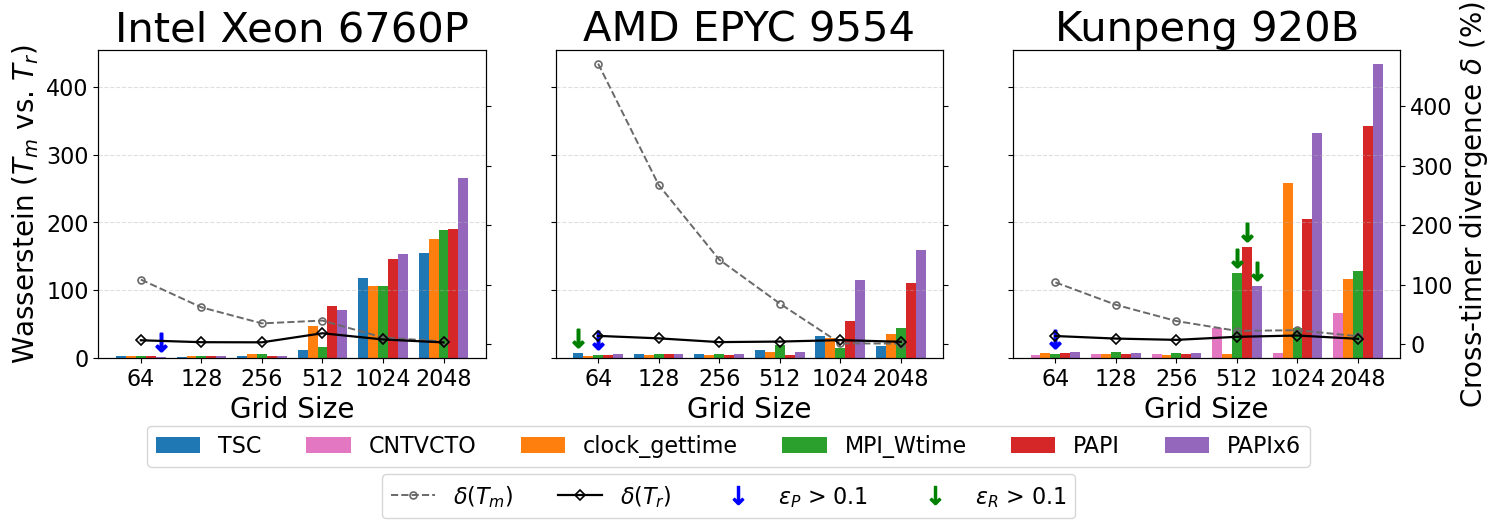

In [7]:
# Cross-timer divergence before (T_m) / after (T_r) + ep/er threshold indicators (stencil)
# divergence delta = mean_t WD(timer, ref) / mean(ref measured time);  ref: x86->tsc, ARM->cntvcto.
# reduction = (sum WD_tm - sum WD_tr) / sum WD_tm  (deviation reduction ratio; column only).
from scipy.stats import wasserstein_distance
from matplotlib.lines import Line2D

REF_TIMER_BY_HOST = {'cgnr6760pn2': 'tsc', 'camd9554n1': 'tsc', 'c920bn3': 'cntvcto'}

# ---- thresholds (tune by hand) ----
EP_THRESHOLD = 0.1  # eps_P over this -> flag
ER_THRESHOLD = 0.1  # eps_R over this -> flag

# ---- fonts (tune by hand) ----
TITLE_FONTSIZE = 30
AXIS_LABEL_FONTSIZE = 20
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16
ARROW_FONTSIZE = 13
# legend vertical offsets (more negative = lower); timer legend above, divergence legend below
TIMER_LEGEND_Y = 0.07
DIV_LEGEND_Y = -0.04


def _wd_seq(a, b):
    if a is None or b is None:
        return np.nan
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return wasserstein_distance(a, b) if (a.size and b.size) else np.nan


def divergence_table(src, group_keys):
    """Cross-timer divergence before (TM) and after (TR), plus deviation reduction ratio.
    delta = mean over non-ref timers of WD(timer, ref) / mean(ref measured time); same base
    for before/after so the two levels are comparable. reduction = (sum_tm - sum_tr)/sum_tm."""
    rows = []
    for gv, g in src.groupby(group_keys):
        gd = dict(zip(group_keys, gv if isinstance(gv, tuple) else (gv,)))
        ref_timer = REF_TIMER_BY_HOST.get(gd['host'])
        ref = g[g['timer'] == ref_timer]
        if ref.empty:
            continue
        ref = ref.iloc[0]
        ref_tm = np.asarray(ref['tm_seq'], dtype=float) if ref['tm_seq'] is not None else None
        base = float(np.mean(ref_tm)) if (ref_tm is not None and ref_tm.size) else np.nan
        tm_ds, tr_ds = [], []
        for _, r in g.iterrows():
            if r['timer'] == ref_timer:
                continue
            d_tm = _wd_seq(r['tm_seq'], ref['tm_seq'])
            d_tr = _wd_seq(r['tr_seq'], ref['tr_seq'])
            if np.isfinite(d_tm):
                tm_ds.append(d_tm)
            if np.isfinite(d_tr):
                tr_ds.append(d_tr)
        s_tm = float(np.sum(tm_ds)) if tm_ds else np.nan
        s_tr = float(np.sum(tr_ds)) if tr_ds else np.nan
        gd['reduction'] = (s_tm - s_tr) / s_tm if (np.isfinite(s_tm) and s_tm > 0) else np.nan
        if gd['reduction'] is np.nan:
            print(f"divergence_table group {gv}: base={base} sum_tm={s_tm} sum_tr={s_tr} reduction={gd['reduction']}")
        if int(gd['size']) == 256:
            print(f"divergence_table group {gv}: base={base} sum_tm={s_tm} sum_tr={s_tr} reduction={gd['reduction']}")

        if np.isfinite(base) and base > 0:
            gd['d_before'] = (np.mean(tm_ds) / base) if tm_ds else np.nan
            gd['d_after'] = (np.mean(tr_ds) / base) if tr_ds else np.nan
        else:
            gd['d_before'] = gd['d_after'] = np.nan
        rows.append(gd)
    return pd.DataFrame(rows)


def _flag_color(ep_v, er_v):
    ep_hi = np.isfinite(ep_v) and ep_v > EP_THRESHOLD
    er_hi = np.isfinite(er_v) and er_v > ER_THRESHOLD
    if ep_hi and er_hi:
        return 'red'
    if ep_hi:
        return 'blue'
    if er_hi:
        return 'green'
    return None


metric_bar = 'wd'
div_df = divergence_table(df, ['kernel', 'host', 'size', 'nsampRatio'])

plot_df = df.copy()
plot_df['timer_label'] = plot_df['timer'].map(TIMER_LABELS).fillna(plot_df['timer'])
plot_df['kernel_label'] = plot_df['kernel'].map(KERNEL_LABELS).fillna(plot_df['kernel'])
plot_df['size_str'] = plot_df['size'].astype(str)
size_order = [str(x) for x in sorted(plot_df['size'].unique())]
plot_df['size_str'] = pd.Categorical(plot_df['size_str'], categories=size_order, ordered=True)

hosts = [host_from_data_folder(p) for p in DATA_FOLDERS]
kernels = sorted(plot_df['kernel'].dropna().unique())

for kernel in kernels:
    kernel_df = plot_df[plot_df['kernel'] == kernel].copy()
    if kernel_df.empty:
        continue
    dk = div_df[div_df['kernel'] == kernel]
    kernel_label = kernel_df['kernel_label'].iloc[0]
    refs = {HOST_LABELS.get(h, h): REF_TIMER_BY_HOST.get(h) for h in hosts}
    print(f'[WD / divergence Tm->Tr + eps]  kernel={kernel_label}  {SHUFFLE_LABEL}  hosts(L->R)={[HOST_LABELS.get(h, h) for h in hosts]}  ref_by_host={refs}')

    gmax = np.nanmax(kernel_df[metric_bar].to_numpy(dtype=float)) if len(kernel_df) else 1.0
    if not np.isfinite(gmax) or gmax <= 0:
        gmax = 1.0
    arrow_dy = 0.05 * gmax

    fig, axes = plt.subplots(1, len(hosts), figsize=(5.6 * len(hosts), 4.4), sharey=True, constrained_layout=False)
    if len(hosts) == 1:
        axes = [axes]

    right_axes = []
    bar_handles = {}          # keyed by timer -> handle, for ordered legend
    before_handle = after_handle = None
    any_red = False
    for ax1, host in zip(axes, hosts):
        host_df = kernel_df[kernel_df['host'] == host]
        ref_timer = REF_TIMER_BY_HOST.get(host)
        ax1.set_title(HOST_LABELS.get(host, host), fontsize=TITLE_FONTSIZE)
        ax1.set_xlabel('Grid Size', fontsize=AXIS_LABEL_FONTSIZE)
        ax1.set_ylabel(r'Wasserstein ($T_m$ vs. $T_r$)' if ax1 is axes[0] else '', fontsize=AXIS_LABEL_FONTSIZE)
        ax1.grid(axis='y', linestyle='--', alpha=0.4)

        ax2 = ax1.twinx()
        right_axes.append(ax2)

        if host_df.empty:
            ax1.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax1.transAxes)
            ax1.set_xticks([])
            ax2.set_yticks([])
            continue

        timers = sorted(host_df['timer'].unique(), key=timer_sort_key)
        x = np.arange(len(size_order))
        width = 0.82 / max(len(timers), 1)
        for i, timer in enumerate(timers):
            sub = host_df[host_df['timer'] == timer].set_index('size_str').reindex(size_order)
            offset = (i - (len(timers) - 1) / 2) * width
            heights = sub[metric_bar].to_numpy(dtype=float)
            b = ax1.bar(x + offset, heights, width=width, label=timer_label(timer), color=TIMER_COLORS.get(timer))
            bar_handles.setdefault(timer, b)
            ep_arr = sub['ep'].to_numpy(dtype=float)
            er_arr = sub['er'].to_numpy(dtype=float)
            for j in range(len(size_order)):
                h = heights[j]
                if not np.isfinite(h):
                    continue
                c = _flag_color(ep_arr[j], er_arr[j])
                if c is None:
                    continue
                if c == 'red':
                    any_red = True
                ax1.plot(x[j] + offset, h + arrow_dy, marker=r'$\downarrow$', linestyle='None',
                         color=c, markersize=ARROW_FONTSIZE, markeredgewidth=1.4, zorder=6, clip_on=False)

        # x ticks: horizontal, with the ref timer's (tsc/cntvct) TM p25/p75 on a second line
        xticklabels = []
        for s in size_order:
            rr = host_df[(host_df['timer'] == ref_timer) & (host_df['size'] == int(s))]
            if len(rr) and rr.iloc[0]['tm_seq'] is not None:
                seq = np.asarray(rr.iloc[0]['tm_seq'], dtype=float)
                p25, p75 = np.quantile(seq, 0.25), np.quantile(seq, 0.75)
                # xticklabels.append(f'{s}\n({p25:.0f}/{p75:.0f})')
                xticklabels.append(f'{s}')
            else:
                xticklabels.append(f'{s}')
        ax1.set_xticks(x)
        ax1.set_xticklabels(xticklabels, rotation=0, fontsize=TICK_FONTSIZE)
        ax1.tick_params(axis='y', labelsize=TICK_FONTSIZE)

        dh = dk[dk['host'] == host]
        db = dh.groupby('size')['d_before'].mean()
        da = dh.groupby('size')['d_after'].mean()
        before_vals = [100.0 * db.get(int(s), np.nan) for s in size_order]
        after_vals = [100.0 * da.get(int(s), np.nan) for s in size_order]
        lb, = ax2.plot(x, before_vals, marker='o', markersize=5, markerfacecolor='none', markeredgewidth=1.2, color='dimgray', linestyle='--', linewidth=1.4)
        la, = ax2.plot(x, after_vals, marker='D', markersize=5, markerfacecolor='none', markeredgewidth=1.2, color='black', linestyle='-', linewidth=1.6)

        print(f"kernel={kernel} h ost={host}  before: {before_vals}  after: {after_vals}")

        before_handle, after_handle = lb, la
        ax2.tick_params(axis='y', labelsize=TICK_FONTSIZE)

    left_lims = [ax.get_ylim() for ax in axes]
    left_ylim = (min(lo for lo, hi in left_lims), max(hi for lo, hi in left_lims))
    for ax in axes:
        ax.set_ylim(left_ylim)
    rlims = [ax.get_ylim() for ax in right_axes]
    rylim = (min(lo for lo, hi in rlims), max(hi for lo, hi in rlims))
    for j, ax in enumerate(right_axes):
        ax.set_ylim(rylim)
        if j == len(right_axes) - 1:
            ax.set_ylabel(r'Cross-timer divergence $\delta$ (%)', fontsize=AXIS_LABEL_FONTSIZE)
        else:
            ax.set_yticklabels([])

    # timer legend (ordered by timer_sort_key), placed at the bottom
    ordered_timers = sorted(bar_handles, key=timer_sort_key)
    fig.legend([bar_handles[t] for t in ordered_timers], [timer_label(t) for t in ordered_timers],
               ncol=min(6, max(1, len(ordered_timers))), fontsize=LEGEND_FONTSIZE,
               loc='upper center', bbox_to_anchor=(0.5, TIMER_LEGEND_Y), frameon=True)

    # divergence legend (below the timer legend): delta lines + eps arrows (+both only if drawn)
    arrow_proxies = [
        Line2D([0], [0], marker=r'$\downarrow$', linestyle='None', color='blue', markersize=ARROW_FONTSIZE, label=fr'$\epsilon_P$ > {EP_THRESHOLD:g}'),
        Line2D([0], [0], marker=r'$\downarrow$', linestyle='None', color='green', markersize=ARROW_FONTSIZE, label=fr'$\epsilon_R$ > {ER_THRESHOLD:g}'),
    ]
    if any_red:
        arrow_proxies.append(Line2D([0], [0], marker=r'$\downarrow$', linestyle='None', color='red', markersize=ARROW_FONTSIZE, label='both'))
    div_handles = [before_handle, after_handle] + arrow_proxies
    div_labels = [r'$\delta(T_m)$', r'$\delta(T_r)$'] + [p.get_label() for p in arrow_proxies]
    fig.legend(div_handles, div_labels, ncol=min(5, len(div_labels)), fontsize=LEGEND_FONTSIZE,
               loc='upper center', bbox_to_anchor=(0.5, DIV_LEGEND_Y), frameon=True)

    fig.subplots_adjust(bottom=0.20, top=0.90, wspace=0.18)

    if SAVE_FIG:
        OUT_DIR.mkdir(parents=True, exist_ok=True)
        out = OUT_DIR / f'{kernel}_{SHUFFLE_LABEL}_wd_div_eper_by_host.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)

    plt.show()

In [8]:
tmp_df = df.join(div_df, lsuffix="_left", rsuffix="_right",how='left').sort_values(['reduction'],ascending=False)[['host_left','size_left','kernel_left','ep','er','reduction']]
tmp_df[tmp_df['size_left'] == 256]

,host_left,size_left,kernel_left,ep,er,reduction
9,cgnr6760pn2,256,jacobi2d5p,0.000853,0.006029,0.937596
15,cgnr6760pn2,256,jacobi2d5p,0.000606,0.005099,0.538867
3,cgnr6760pn2,256,jacobi2d5p,0.001587,0.018512,0.448157
63,c920bn3,256,jacobi2d5p,0.000444,0.011958,NaN
69,c920bn3,256,jacobi2d5p,0.000000,0.024615,NaN
75,c920bn3,256,jacobi2d5p,0.001039,0.015541,NaN
81,c920bn3,256,jacobi2d5p,0.002158,0.015726,NaN
87,c920bn3,256,jacobi2d5p,0.000000,0.025292,NaN
33,camd9554n1,256,jacobi2d5p,0.012964,0.019740,NaN
39,camd9554n1,256,jacobi2d5p,0.000482,0.004785,NaN


In [9]:
# Per-kernel: grid sizes where ALL hosts' ALL timers satisfy ep <= EP_THRESHOLD and er <= ER_THRESHOLD.
print(f'Qualifying grid sizes (every host/timer has ep <= {EP_THRESHOLD:g} and er <= {ER_THRESHOLD:g}):')
for kernel in sorted(df['kernel'].dropna().unique()):
    kdf = df[df['kernel'] == kernel]
    good = []
    for size, sdf in kdf.groupby('size'):
        if (sdf['ep'] <= EP_THRESHOLD).all() and (sdf['er'] <= ER_THRESHOLD).all():
            good.append(int(size))
    print(f'  {KERNEL_LABELS.get(kernel, kernel)} ({kernel}): {sorted(good)}')

Qualifying grid sizes (every host/timer has ep <= 0.1 and er <= 0.1):
  2D 5-Point Jacobi Stencil (jacobi2d5p): [128, 256, 1024, 2048]


# Filt Plot

In [10]:
entries['nsamp'].unique()

array([ 3382,   170,  8487,   310,   742,   101,  3474,   358,  8624,
         498,   874,   289,  3488,   368,  8549,   508,   886,   299,
        3067,   165,  8174,   304,   599,    95,  3372,   172,  8482,
         313,   730,   104,  7342,   186, 18627,   341,   668,   108,
        7450,  1102, 18472,  1272,  1660,  1024,  1117, 18333,  1288,
        1675,  1040,  7326, 18658,   325,   651,  7356,   201, 18672,
         354,   682,   122,  5713,   246, 12471,   435,  1290,   130,
        4843,   188, 11223,   348,  1044,  5917,   391, 12441,   551,
        5858,   406, 12326,   565,   319,  5668,   216, 12542,   375,
        1261,   114])

[FILT CDF]  kernel=2D 5-Point Jacobi Stencil  cgnr6760pn2-shuffle1_camd9554n1-shuffle1_c920bn3-shuffle1  np=64  size=64  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=87.00 ns  tr_median=55.00 ns
host=cgnr6760pn2 timer=cgt  tm_median=94.00 ns  tr_median=58.00 ns
host=cgnr6760pn2 timer=wtime  tm_median=97.00 ns  tr_median=59.00 ns
host=cgnr6760pn2 timer=papi  tm_median=262.74 ns  tr_median=62.74 ns
host=cgnr6760pn2 timer=papix6  tm_median=271.91 ns  tr_median=62.91 ns
host=camd9554n1 timer=tsc  tm_median=65.50 ns  tr_median=45.50 ns
host=camd9554n1 timer=cgt  tm_median=76.00 ns  tr_median=56.00 ns
host=camd9554n1 timer=wtime  tm_median=79.00 ns  tr_median=58.00 ns
host=camd9554n1 timer=papi  tm_median=667.07 ns  tr_median=36.07 ns
host=camd9554n1 timer=papix6  tm_median=675.19 ns  tr_median=44.19 ns
host=c920bn3 timer=cntvcto  tm_median=75.50 ns  tr_median=55.50 ns
host=c920bn3 timer=cgt  tm_median=94.38 ns  tr_me

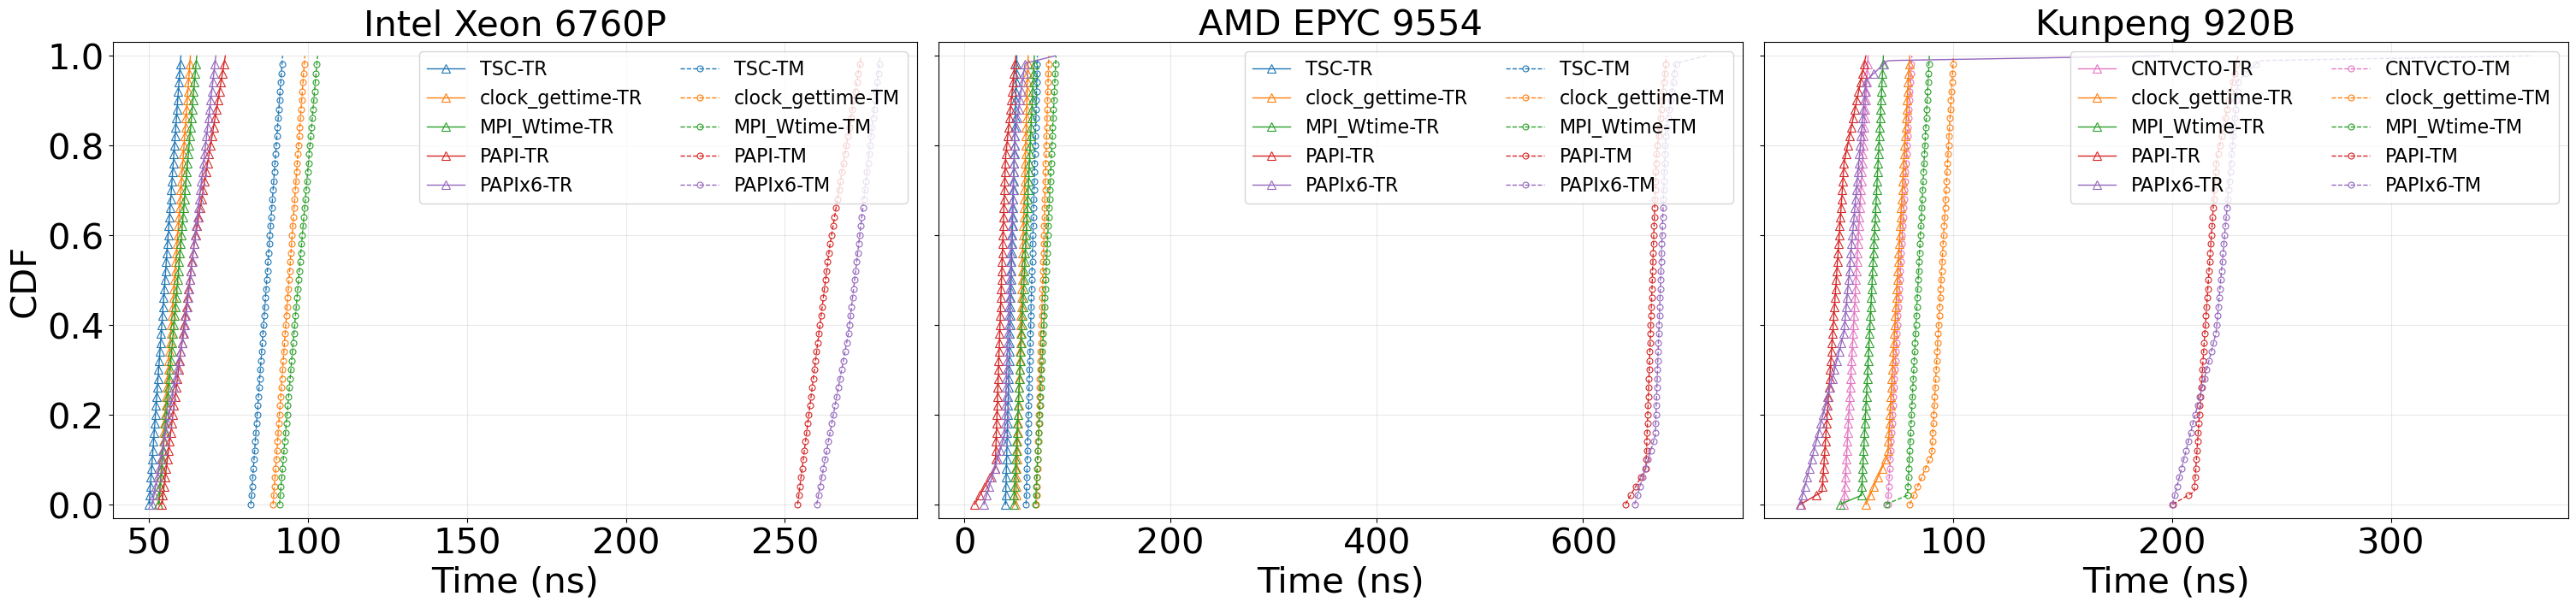

[FILT CDF]  kernel=2D 5-Point Jacobi Stencil  cgnr6760pn2-shuffle1_camd9554n1-shuffle1_c920bn3-shuffle1  np=64  size=128  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=151.50 ns  tr_median=119.50 ns
host=cgnr6760pn2 timer=cgt  tm_median=156.50 ns  tr_median=120.50 ns
host=cgnr6760pn2 timer=wtime  tm_median=161.00 ns  tr_median=123.00 ns
host=cgnr6760pn2 timer=papi  tm_median=327.00 ns  tr_median=127.00 ns
host=cgnr6760pn2 timer=papix6  tm_median=335.85 ns  tr_median=126.85 ns
host=camd9554n1 timer=tsc  tm_median=115.50 ns  tr_median=95.50 ns
host=camd9554n1 timer=cgt  tm_median=126.00 ns  tr_median=106.00 ns
host=camd9554n1 timer=wtime  tm_median=133.94 ns  tr_median=113.73 ns
host=camd9554n1 timer=papi  tm_median=715.49 ns  tr_median=84.49 ns
host=camd9554n1 timer=papix6  tm_median=724.59 ns  tr_median=93.59 ns
host=c920bn3 timer=cntvcto  tm_median=134.63 ns  tr_median=110.35 ns
host=c920bn3 timer=cgt  tm_median

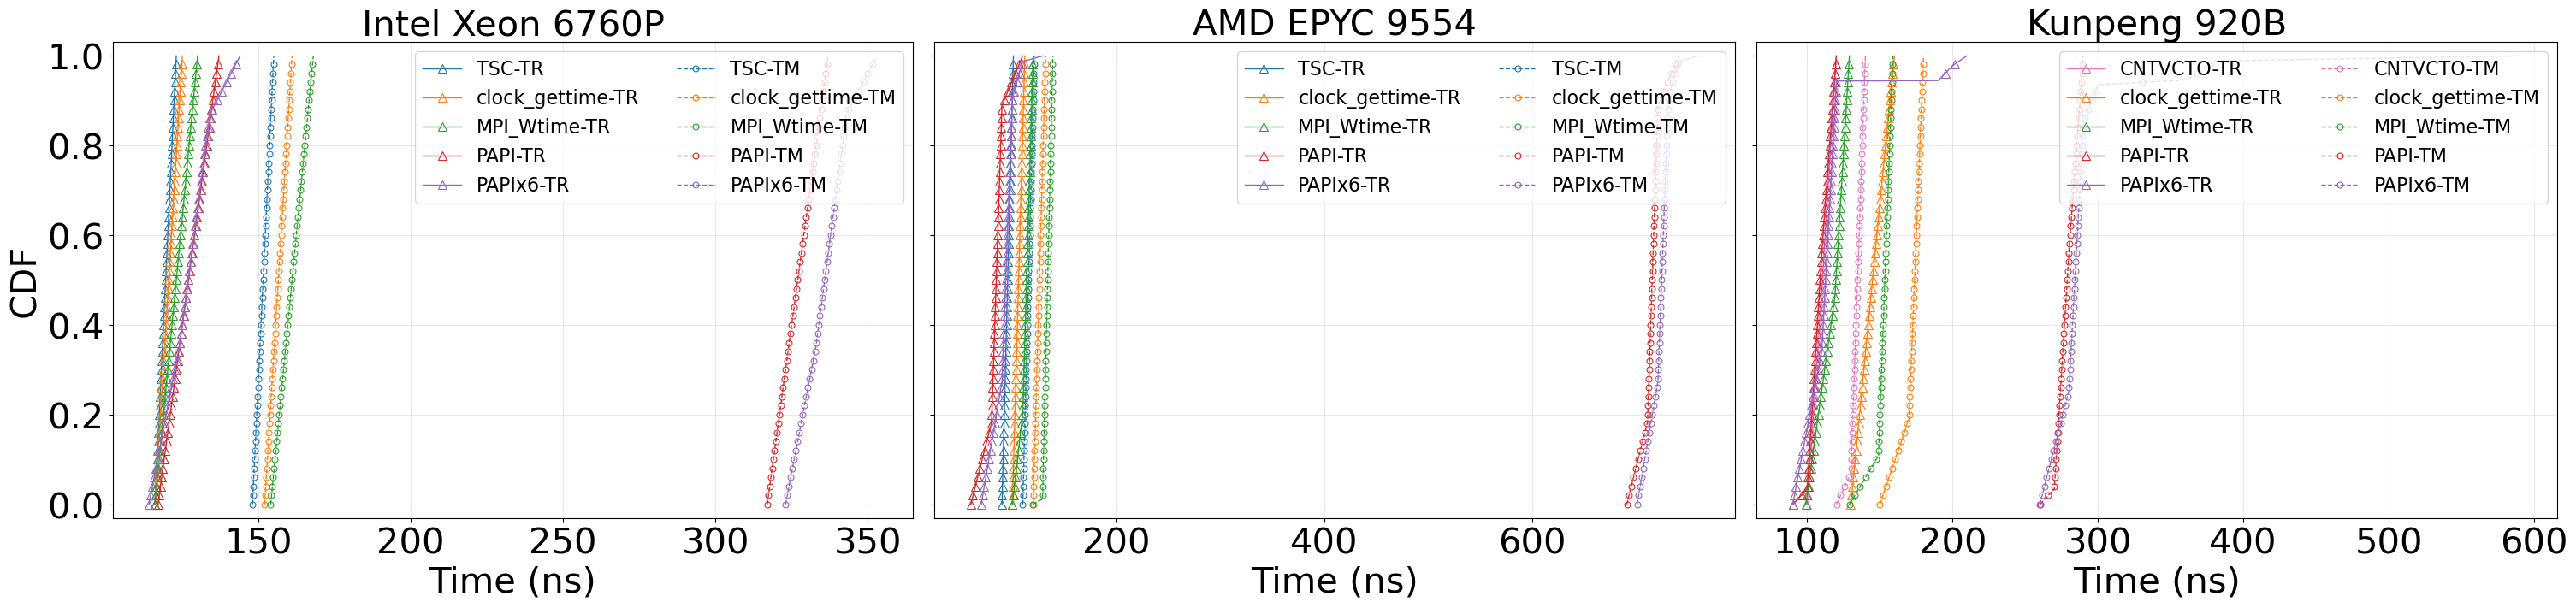

[FILT CDF]  kernel=2D 5-Point Jacobi Stencil  cgnr6760pn2-shuffle1_camd9554n1-shuffle1_c920bn3-shuffle1  np=64  size=256  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=278.07 ns  tr_median=245.03 ns
host=cgnr6760pn2 timer=cgt  tm_median=283.90 ns  tr_median=246.68 ns
host=cgnr6760pn2 timer=wtime  tm_median=285.79 ns  tr_median=247.55 ns
host=cgnr6760pn2 timer=papi  tm_median=454.13 ns  tr_median=253.13 ns
host=cgnr6760pn2 timer=papix6  tm_median=464.14 ns  tr_median=255.14 ns
host=camd9554n1 timer=tsc  tm_median=216.61 ns  tr_median=196.60 ns
host=camd9554n1 timer=cgt  tm_median=224.45 ns  tr_median=204.36 ns
host=camd9554n1 timer=wtime  tm_median=232.22 ns  tr_median=209.80 ns
host=camd9554n1 timer=papi  tm_median=824.20 ns  tr_median=193.20 ns
host=camd9554n1 timer=papix6  tm_median=833.11 ns  tr_median=202.11 ns
host=c920bn3 timer=cntvcto  tm_median=243.88 ns  tr_median=223.19 ns
host=c920bn3 timer=cgt  tm_med

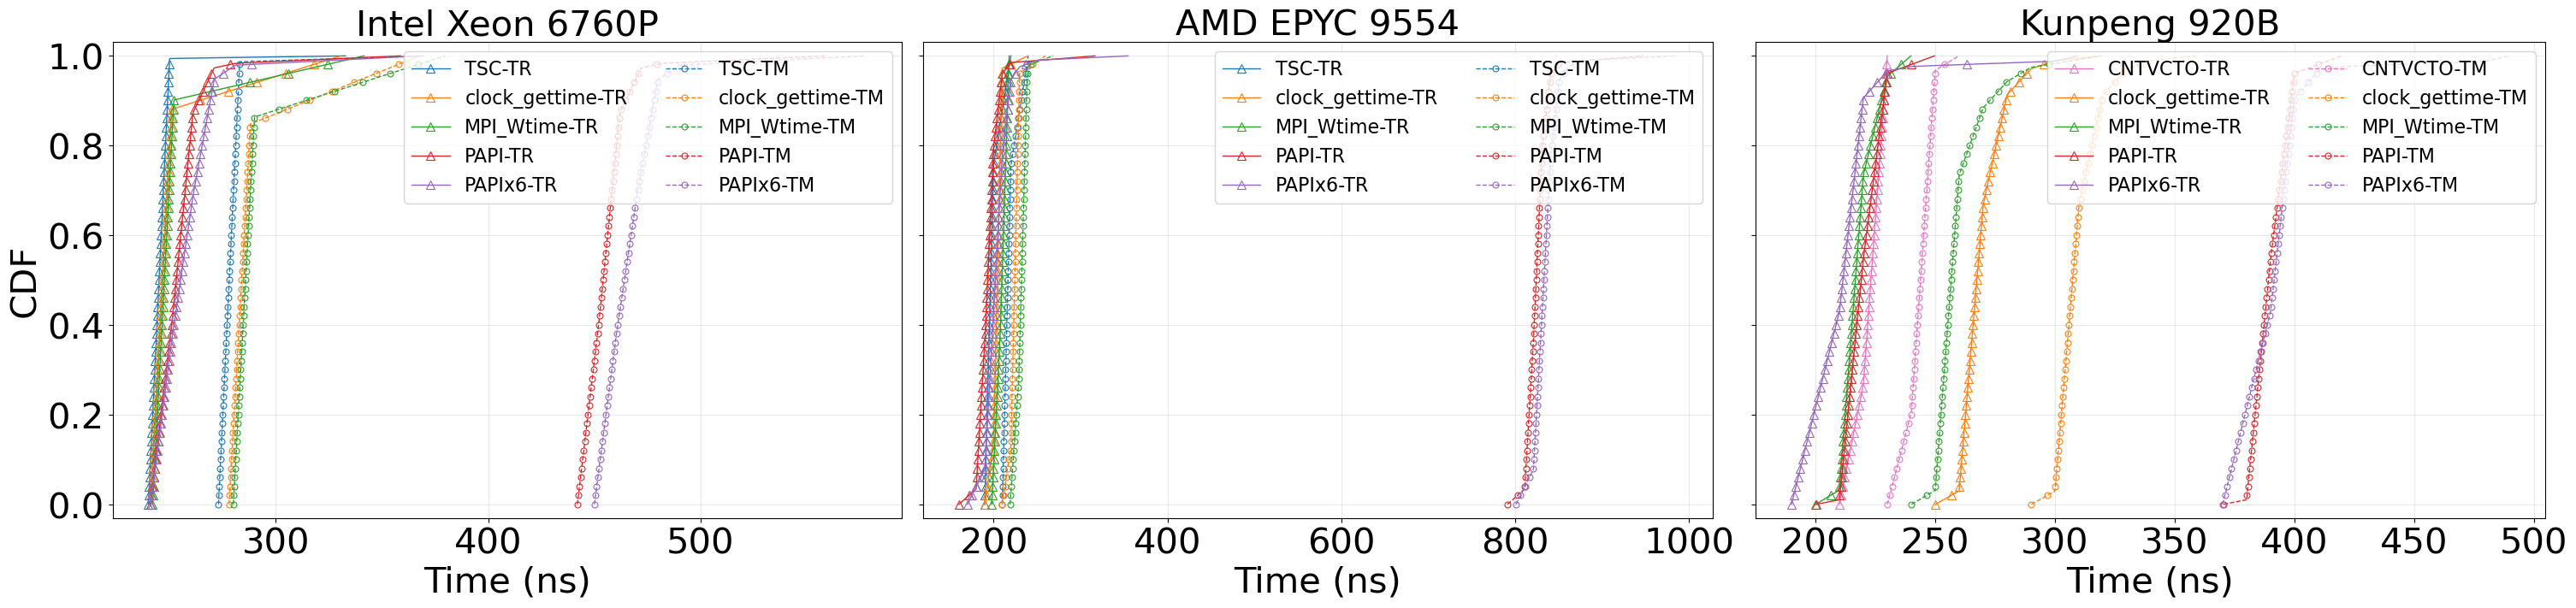

[FILT CDF]  kernel=2D 5-Point Jacobi Stencil  cgnr6760pn2-shuffle1_camd9554n1-shuffle1_c920bn3-shuffle1  np=64  size=512  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=545.38 ns  tr_median=510.90 ns
host=cgnr6760pn2 timer=cgt  tm_median=674.94 ns  tr_median=619.38 ns
host=cgnr6760pn2 timer=wtime  tm_median=662.83 ns  tr_median=619.07 ns
host=cgnr6760pn2 timer=papi  tm_median=794.98 ns  tr_median=573.84 ns
host=cgnr6760pn2 timer=papix6  tm_median=805.60 ns  tr_median=577.36 ns
host=camd9554n1 timer=tsc  tm_median=422.97 ns  tr_median=398.54 ns
host=camd9554n1 timer=cgt  tm_median=439.59 ns  tr_median=399.92 ns
host=camd9554n1 timer=wtime  tm_median=443.29 ns  tr_median=404.83 ns
host=camd9554n1 timer=papi  tm_median=1071.13 ns  tr_median=440.13 ns
host=camd9554n1 timer=papix6  tm_median=1080.63 ns  tr_median=448.63 ns
host=c920bn3 timer=cntvcto  tm_median=721.44 ns  tr_median=525.53 ns
host=c920bn3 timer=cgt  tm_m

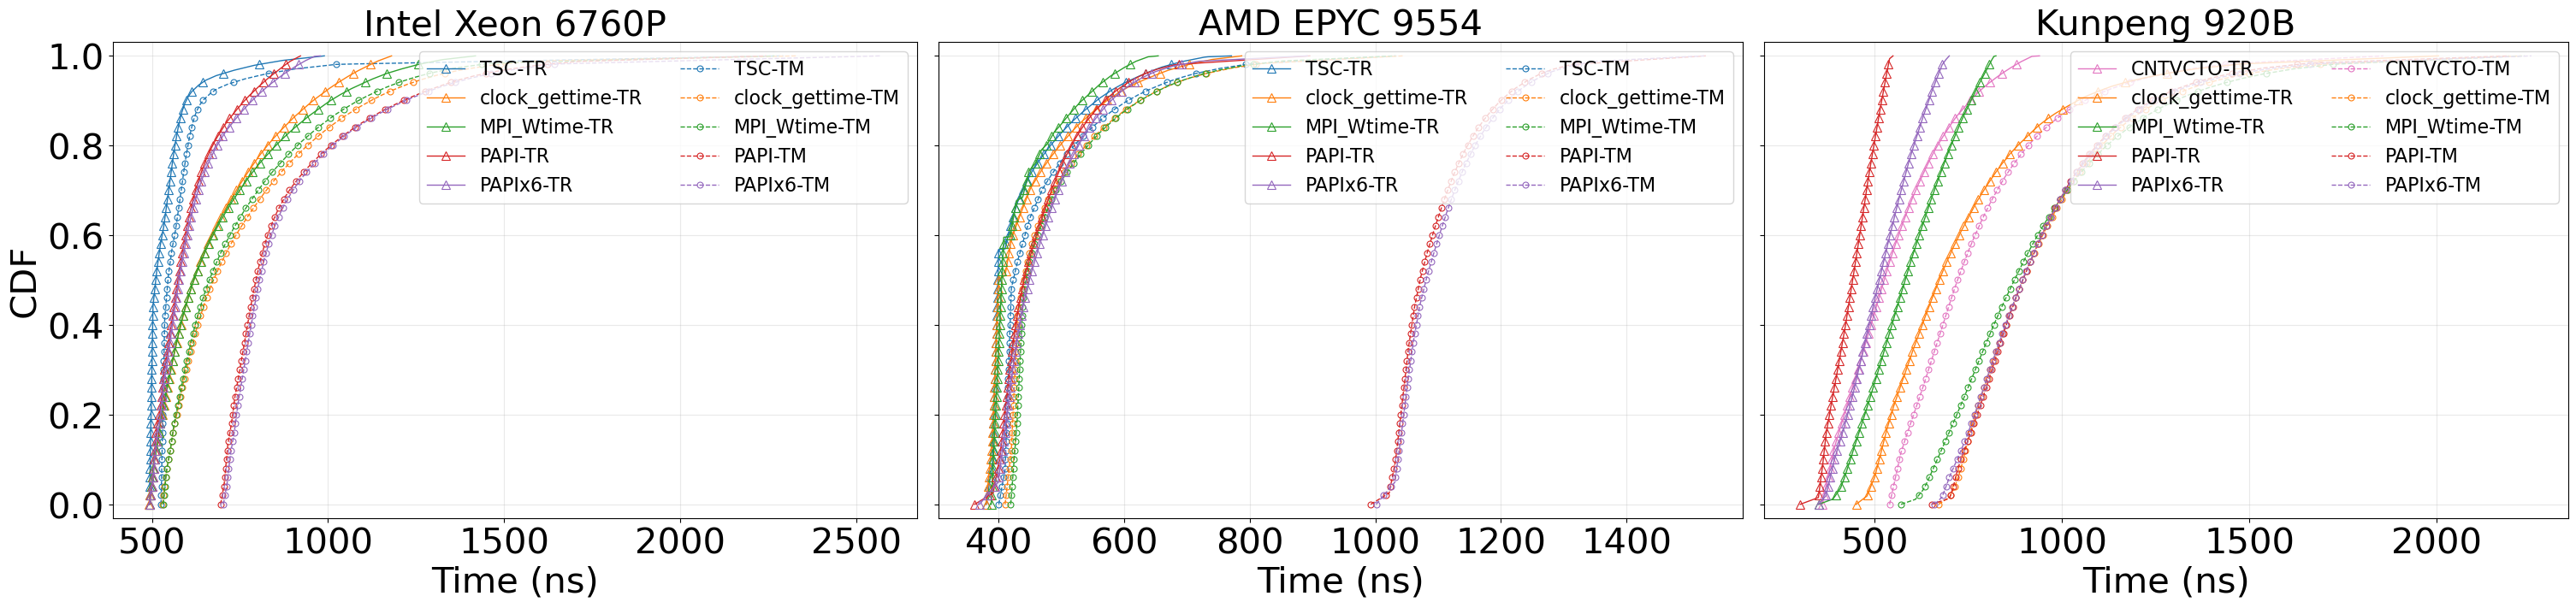

[FILT CDF]  kernel=2D 5-Point Jacobi Stencil  cgnr6760pn2-shuffle1_camd9554n1-shuffle1_c920bn3-shuffle1  np=64  size=1024  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=2786.34 ns  tr_median=2712.30 ns
host=cgnr6760pn2 timer=cgt  tm_median=3072.42 ns  tr_median=2995.08 ns
host=cgnr6760pn2 timer=wtime  tm_median=3063.74 ns  tr_median=2985.80 ns
host=cgnr6760pn2 timer=papi  tm_median=3156.31 ns  tr_median=2896.02 ns
host=cgnr6760pn2 timer=papix6  tm_median=3168.85 ns  tr_median=2896.15 ns
host=camd9554n1 timer=tsc  tm_median=4718.24 ns  tr_median=4677.10 ns
host=camd9554n1 timer=cgt  tm_median=4727.88 ns  tr_median=4676.19 ns
host=camd9554n1 timer=wtime  tm_median=4741.31 ns  tr_median=4692.66 ns
host=camd9554n1 timer=papi  tm_median=4803.32 ns  tr_median=4143.16 ns
host=camd9554n1 timer=papix6  tm_median=4797.56 ns  tr_median=4100.42 ns
host=c920bn3 timer=cntvcto  tm_median=3342.76 ns  tr_median=3261.11 ns
host=c9

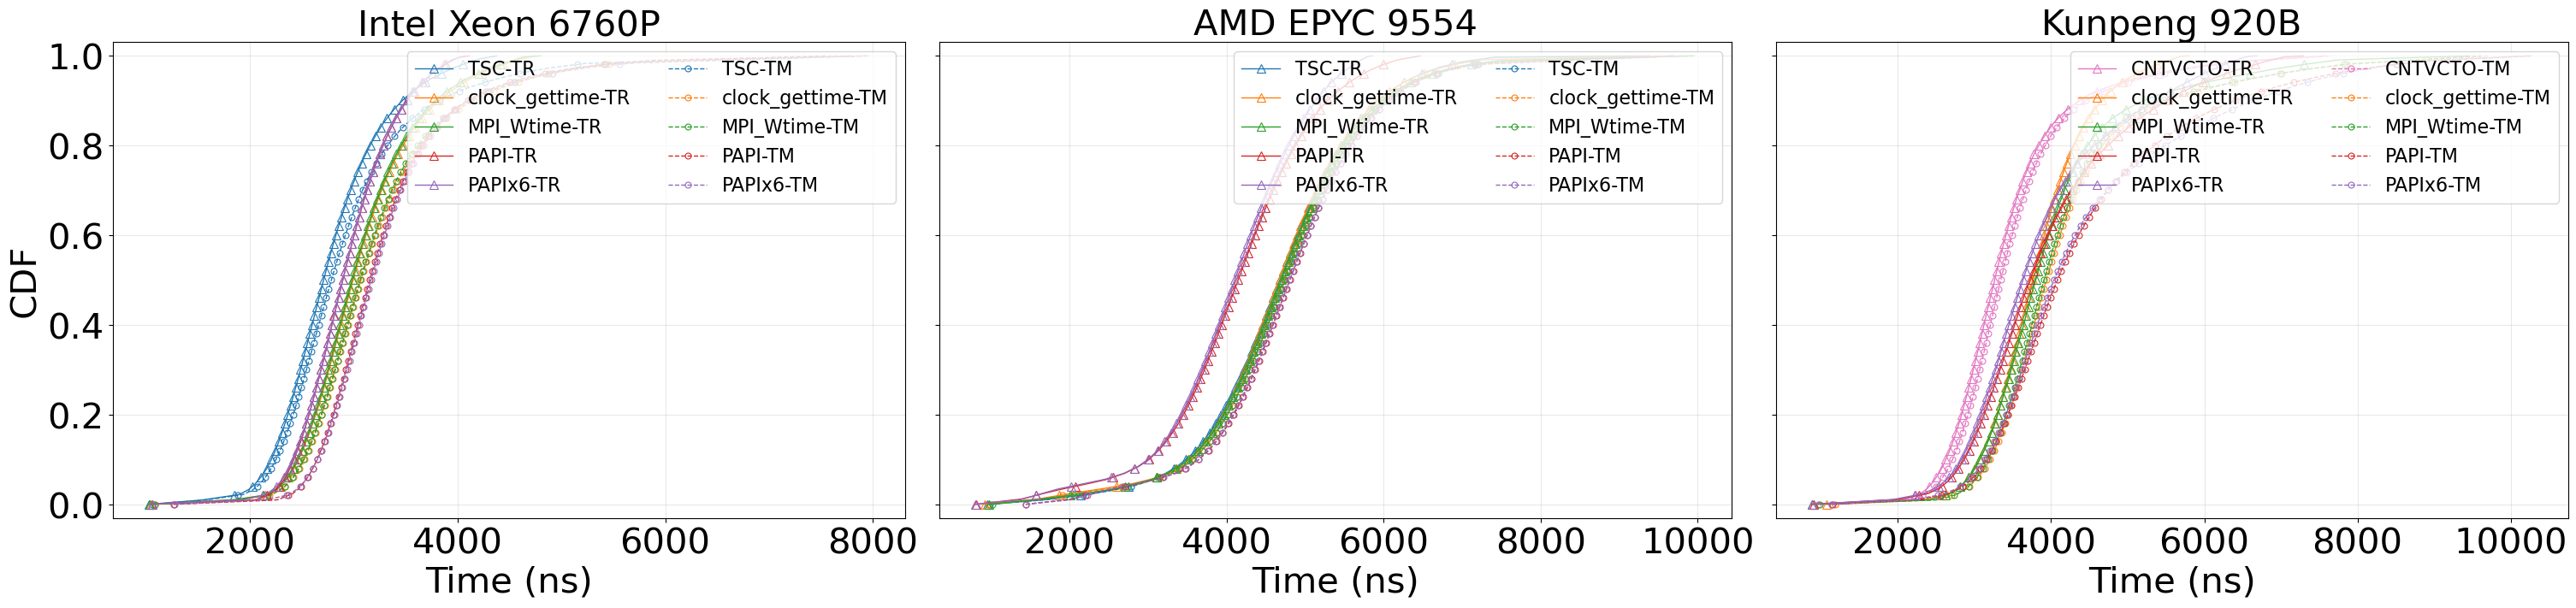

[FILT CDF]  kernel=2D 5-Point Jacobi Stencil  cgnr6760pn2-shuffle1_camd9554n1-shuffle1_c920bn3-shuffle1  np=64  size=2048  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=7426.73 ns  tr_median=7336.90 ns
host=cgnr6760pn2 timer=cgt  tm_median=7711.46 ns  tr_median=7607.07 ns
host=cgnr6760pn2 timer=wtime  tm_median=7707.13 ns  tr_median=7587.64 ns
host=cgnr6760pn2 timer=papi  tm_median=7834.87 ns  tr_median=7551.32 ns
host=cgnr6760pn2 timer=papix6  tm_median=7767.27 ns  tr_median=7465.22 ns
host=camd9554n1 timer=tsc  tm_median=12027.84 ns  tr_median=11977.22 ns
host=camd9554n1 timer=cgt  tm_median=12013.92 ns  tr_median=11935.64 ns
host=camd9554n1 timer=wtime  tm_median=12036.44 ns  tr_median=11961.25 ns
host=camd9554n1 timer=papi  tm_median=11910.50 ns  tr_median=11205.78 ns
host=camd9554n1 timer=papix6  tm_median=11826.15 ns  tr_median=11090.28 ns
host=c920bn3 timer=cntvcto  tm_median=7742.55 ns  tr_median=7562.96 

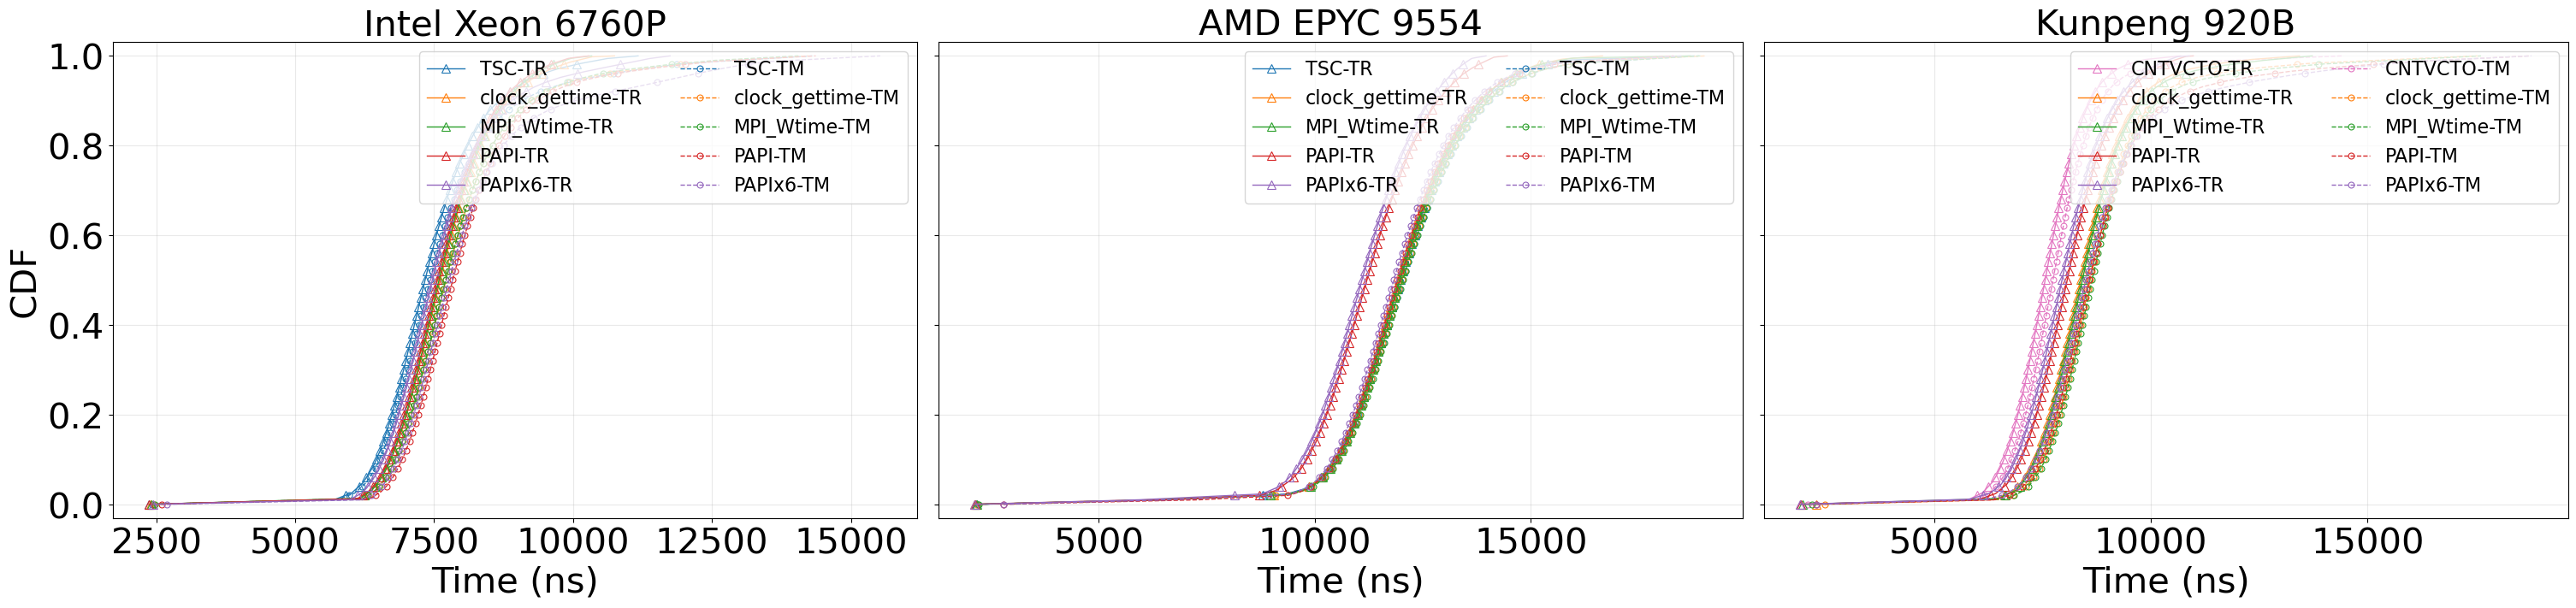

In [11]:
# ---- font sizes (tune here) ----
FILT_TITLE_FONTSIZE  = 30
FILT_LABEL_FONTSIZE  = 30
FILT_TICK_FONTSIZE   = 30
FILT_LEGEND_FONTSIZE = 16

plot_df = df[df['timer'] != 'likwid'].copy()

if plot_df.empty:
    raise RuntimeError('No entries with tr_seq/tm_seq to plot')

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

hosts = [host_from_data_folder(p) for p in DATA_FOLDERS]


def seq_ecdf(seq):
    """ECDF (x, y) from a sample array, clipped to QUANTILE_DROP."""
    s = np.sort(np.asarray(seq, dtype=float))
    n = s.size
    if n == 0:
        return s, s
    y = (np.arange(n) + 0.5) / n
    keep = y <= QUANTILE_DROP
    return s[keep], y[keep]


def _ordered_tr_tm(ax):
    """Legend handles ordered so each row pairs timer-TR, timer-TM (ncol=2, column-major)."""
    h, l = ax.get_legend_handles_labels()
    tr = [(hh, ll) for hh, ll in zip(h, l) if ll.endswith('-TR')]
    tm = [(hh, ll) for hh, ll in zip(h, l) if ll.endswith('-TM')]
    ordered = tr + tm
    return [hh for hh, ll in ordered], [ll for hh, ll in ordered]


for (kernel, np_val, size, nsamp_ratio), group_all in plot_df.groupby(['kernel', 'np', 'size', 'nsampRatio'], sort=True):
    # 0630: this notebook is for the Jacobi-after full size sweep; keep every Jacobi size.
    if kernel != 'jacobi2d5p':
        continue
    
    print(f'[FILT CDF]  kernel={KERNEL_LABELS.get(kernel, kernel)}  {SHUFFLE_LABEL}  np={np_val}  size={size}  nsampRatio={nsamp_ratio}  hosts(L->R)={[HOST_LABELS.get(h, h) for h in hosts]}')
    fig, axes = plt.subplots(1, len(hosts), figsize=(10.0 * len(hosts), 7), sharey=True, constrained_layout=True)
    if len(hosts) == 1:
        axes = [axes]

    for ax, host in zip(axes, hosts):
        group = group_all[group_all['host'] == host].sort_values('timer', key=lambda s: s.map(timer_sort_key))

        for _, row in group.iterrows():
            timer = row['timer']
            color = TIMER_COLORS.get(timer)
            label = timer_label(timer)

            if row['tm_seq'] is None or row['tr_seq'] is None:
                continue

            tm_x, tm_y = seq_ecdf(row['tm_seq'])
            tr_x, tr_y = seq_ecdf(row['tr_seq'])

            row['tm_median'] = np.median(row['tm_seq'])
            row['tr_median'] = np.median(row['tr_seq'])
            print(f"host={row['host']} timer={row['timer']}  tm_median={row['tm_median']:.2f} ns  tr_median={row['tr_median']:.2f} ns")

            tm_me = max(1, len(tm_x) // 50)
            tr_me = max(1, len(tr_x) // 50)

            ax.plot(tm_x, tm_y, label=f'{label}-TM', color=color, linestyle='--', linewidth=1.0, marker='.', markevery=tm_me, markersize=10, markerfacecolor='none', markeredgewidth=0.8)
            ax.plot(tr_x, tr_y, label=f'{label}-TR', color=color, linestyle='-', linewidth=1.0, marker='^', markevery=tr_me, markersize=7, markerfacecolor='none', markeredgewidth=0.8)

        ax.set_title(f"{HOST_LABELS.get(host, host)}", fontsize=FILT_TITLE_FONTSIZE)
        ax.set_xlabel('Time (ns)', fontsize=FILT_LABEL_FONTSIZE)
        ax.set_ylim(-0.03, QUANTILE_DROP + 0.03)
        ax.grid(True, alpha=0.28)
        ax.tick_params(axis='both', labelsize=FILT_TICK_FONTSIZE)
        oh, ol = _ordered_tr_tm(ax)
        if oh:
            ax.legend(oh, ol, ncol=2, fontsize=FILT_LEGEND_FONTSIZE, loc='upper right')

    for ax in axes:
        ax.set_ylim(-0.03, QUANTILE_DROP + 0.03)

    axes[0].set_ylabel('CDF', fontsize=FILT_LABEL_FONTSIZE)

    if SAVE_FIG:
        out = OUT_DIR / f'{kernel}_{SHUFFLE_LABEL}_np{np_val}_size{size}_ratio{nsamp_ratio}_tm_tr_by_host.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)

    plt.show()
